## Project 2. Clustering using k-means, k-medoids, and hierarchical clustering

### Due date: Wednesday, May 13, 2026, 11:59pm

### Student ID: 921914042
### Student Name:Arezoo Ghasemzadeh

## Methodology Part

Answer the following questions, and submit your answers to problems 1 and 2 through canvas (either a picture or a scan - clearly readable). For Problem 3, see instructions given in the formulation of the problem.

**Methodology Problem 1:** Let $X_1,\ldots,X_n$ be a sample of real valued data, and let $\overline{X}_n = \frac{1}{n}\sum_{j=1}^n X_j$ denote the sample mean. 

a. Show that

$$\overline{X}_n = \arg\min_{a \in {\mathbb R}}\sum_{j=1}^n (X_j - a)^2.$$

b. Now consider a sample $X_1,\ldots,X_n$ of $d$-dimensional feature vectors, $d \ge 2$, and let $\overline{X}_n$ be the sample mean (also a $d$-dimensional vector). Show that

$$\overline{X}_n = \arg\min_{a \in {\mathbb R}^d}\sum_{j=1}^n \|X_j - a\|^2.$$

**Methodology Problem 2:** Let $A= (a_{ij})_{i,j=1,\ldots,n}$ be an $(n \times n)$-matrix. Let $ \|A \|^2_{F} = \sum_{i=1}^n\sum_{j=1}^n a^2_{ij}.$ Show that

$$ \|A \|^2_{F} = {\rm trace}\big(A^\top A\big),$$

and explain how this quantity can be expressed through the eigenvalues of $A$.


## Data Analysis Part

### <font color="Red"> Note: </font> 

- #### YOU HAVE TO INSTALL basemap, whether you work on colab or not... <font color="Red">It is highly recommended to work on Colab </font>  if you are not experienced in using python, because installing basemap can cause unexpected issues. In contrast to that, things seem to work smoothly on colab.

In [108]:
## INSTALLING BASEMAP

## Whether working on colab, first run the following command to install basemap (uncomment the below once you are ready to install)

# ! pip install basemap

## This will run a shell command and should also work on your local machine.


In [109]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Union
# Do not use any packages below in your code before part 4
import pandas as pd
from mpl_toolkits.basemap import Basemap # you need to run `pip install basemap` in venv. 
                                        # This will reinstall numpy and some other packages with certain versions 
from pylab import rcParams
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans 
#use sklearn to do clustering only if you decide not to get credit from part 1~3

%matplotlib inline

## Outline

In this project, you will 
- I. write a python class to implement the k-means and k-medoids methods, along with a method for comparing clustering results; 
- II. use the python classes you write to do some data analysis with both simulated data and also a real data set.

Note, that one can do the majority of section II without finishing section I by using functions in sklearn, but this automatically leads to zero credit for parts 1-3.

This project is much more challenging and time consuming than the last one. Start early!

## Part 1. Implementing k-means algorithm <font color="red">  </font>

Complete what is missing to implement the k-means algorithm. Read the explicit requirements inside the functions carefully.

In [110]:
class k_means:
    
    def __init__(self, data: np.ndarray, d: int, k: int , tol: float, max_iter: int, seed: int = 20):
        """
        data: data to cluster
        d:dimension of the data
        k: prespecified number of clusters
        tol: convergence criterion
        max_iter: maximum number of iterations allowed
        """
        ### self.partition[i] stores the indices of the points belonging to cluster i
        ### self.labels[i] is the label (ranging from 0-k) for data point i
        
        self.partitions = {i: [] for i in range(k)}
        self.centers = np.zeros((k, d))
        self.next_centers = np.zeros((k, d))
        self.labels = np.array([])
        self.d = d
        self.n = data.shape[0]
        self.counter = 0
        self.seed = seed
        
        ### suggested number of lines: <= 5
        ### initialize all the necessary variables to store the parameters used in the algorithm
        ### 
        ### your code starts here

        self.data = data 
        self.k = k
        self.tol = tol
        self.max_iter = max_iter
        self.cost = 0 
        
        ### end of your code
    
    
    def initialize_centers(self, method: int): # Pick random starting centers
        """
        method = 0:
        pick the first k points from the data as centers

        method = 1:
        randomly pick k points from the data as centers
        """
        if method == 0:
            self.centers = self.data[:self.k, :]
    
        elif method == 1:
            np.random.seed(20)
            ### suggested number of lines: = 1
            ### use np.random.choice to initialize the centers;
            

            # randomly picks k distinct rows indices from the data and sets those rows as 
            # the initial centers
            self.centers = self.data[np.random.choice(self.n, self.k, replace=False), :]
        

    def search(self): # Assign points to clusters, then recompute centers
        """
        update the partitions and then calculate the next centers; 
        here we use centroids for the k-means method
        """
        self.partitions = {i: [] for i in range(self.k)}
        self.next_centers = np.array([])

        ### suggested number of lines: <= 10
        ### update the self.partitions based on current self.centers;
        ### update the self.next_centers based on self.partitions;
        ### your code starts here
        
        # Steps:

        # Loop over points: visit every data point one at a time
        # Compute distances: measure how far is it from each cluster center
        # argmin: find the nearest center
        # append to partitions: assign the point to that cluster
        # next_centers = recompute each cluster's center as the mean of its assigned points

    
        for i in range(self.n):
            distances = [np.linalg.norm(self.data[i] - self.centers[c]) for c in range(self.k)]
            cluster = np.argmin(distances)
            self.partitions[cluster].append(i)

        self.next_centers = np.array([
            np.mean(self.data[self.partitions[c]], axis=0) if self.partitions[c] else self.centers[c]
            for c in range(self.k)
        ])
        
        
        
        ### end of your code
            
            
    def is_updated(self):
        """
        return True if update is completed, meaning that the algorithm has not yet converged; 
        return False otherwise;
        The convergence criterion is the sum of absolute differences between 
        self.centers and self.next_centers being smaller than tol;
        """
        ### suggested number of lines: <= 6
        ### your code starts here

        # Sum the absolute difference between old and new centers. 
        # If it's smaller than tol, convergence is reach
        # Return False (no update needed)
        # Otherwise update self.centers and return "True" to keep iterating

        diff = np.sum(np.abs(self.centers - self.next_centers))
        if diff < self.tol:
            return False
        else:
            self.centers = self.next_centers.copy()
            return True
        
        
        ### end of your code

        
    def fit_model(self):
        """
        function to fit the k-means algorithms using the above functions
        """
        self.initialize_centers(1)
        self.counter = 0
        
        ### suggested number of lines: <= 15
        ### come up with a control flow to use self.search and self.is_updated to finish the label assignments
        ### print "Maximum Number of Iteration Reached!" if the number of iterations = the maximum iterations allowed
        ### print "Convergence Reached! Number of Iterations: " plus the number of iterations when the label assignment 
        ### has completed by reaching the convergence criterion;
        
        ### your code starts here

        # Keep calling search() then is_updated(). If is_updated() returns False, convergence happened -- print and break.
        # The else on a while loop only runs if we never hit break, meaning we exhausted max_iter.

        while self.counter < self.max_iter:
            self.search()
            self.counter += 1
            if not self.is_updated():
                print("Convergence Reached! Number of iterations: " + str(self.counter))
                break
        else:
            # this 'else' belongs to the WHILE loop, not the if statement
            # it only runs if we never hit 'break', meaning max_iter was exhausted
            print("Maximum number of Iteration Reached!")
        
        
    
        
        ### your code ends here
    
        self.get_labels()

        
    def set_k(self, k: int):
        self.k = k
        
    def predict(self, pt: np.ndarray):
        distances = [np.linalg.norm(pt-c) for c in self.centers]
        cluster_label = distances.index(min(distances))
        return cluster_label

    
    def get_labels(self):
        ### suggested number of lines: <= 6
        ### write an api to update self.labels based on self.partitions
        ### your code starts here
        
        # create a zero array of length n, then for each cluster and its list of point indices, set lables[idx] = cluster_number

        self.labels = np.zeros(self.n, dtype=int)
        for cluster, indices in self.partitions.items():
            for idx in indices:
                self.labels[idx] = cluster
        
        ### end of your code
        
        return self.labels
    
    def get_centers(self):
        return self.centers
    
    def get_clusters(self):
        return self.partitions

    def get_cost(self):
        """
        Here we use within cluster sum of squares as cost 
        """
        ### suggested number of lines: <= 6
        ### write an api to get the cost based on self.partition and self.next_centers (why?)
        ### your code starts here
        
        # For each cluster, grab the data points belonging to it. compute the squared distance of each point from the cluster's center, sum them all up.
        # We use self.next_centers because after search() runs, next_centers hold the freshly computed centroids that match the
        # current partitions -- self.centers 

        self.cost = 0
        for c in range(self.k):
            if self.partitions[c]:
                cluster_data = self.data[self.partitions[c]]
                self.cost += np.sum((cluster_data - self.next_centers[c]) ** 2)

        
        ### end of your code
        return self.cost
        
    def plot_clusters(self):
        if self.d > 2:
            print("Dimension too large!")
            return 
        if self.labels.size == 0:
            self.fit_model()
        plt.scatter(self.data[:, 0] , self.data[:, 1], c=self.labels, s=3)
        plt.scatter(np.array(self.centers)[:, 0], np.array(self.centers)[:, 1], marker='*', c=list(range(self.k)), s=300)
        plt.show()

## Part 2. Implementing criteria to evaluate clustering algorithms 

Write a class to implement the clustering evaluation metric "adjusted Rand index". Note that, in contrast to the silhouette score discussed in class, the adjusted Rand index is a measure the is used for *comparing* two clustering results, meaning that we need two sets of clustering labels. So we either have two different clustering methods, or, when running simulations, or using labeled data, we know the set of "true" labels (even though we apply the clustering algorithm without using the labels). In the latter case, we can compare a clustering result with the "truth". To learn about the adjusted Rand index, find more details here: https://en.wikipedia.org/wiki/Rand_index.

Notes:

**Adjusted Rand Index**: ARI measures how much the ground truth labels vs. the labels the clutering algorithm predicted agree, accounting for chance.

* This ranges from 1= perfect agreement, 0 = random, negative = worse than random

**Contingency matrix**: table where:
* rows = true label classes
* columns = predicted cluster
* cell [i][j] = how many points have true label i AND predicted label j 

In [111]:
class clustering_eval_metrics:
    def __init__(self, labels: np.ndarray, true_labels=None): # label must be between 0 to number_of_labels - 1
        """
        labels: list of labels that are from the clustering algorithm, for example, from the get_labels method in
                the above k_means class
        true_labels: the ground truth of the labels
        """
        self.labels = labels
        self.true_labels = true_labels
        self.cmat = None # this is the contingency table you need to construct
        self.ars = None # this is the adjusted rand score
        
    def set_true_labels(self, true_labels):
        self.true_labels = np.array(true_labels)
    
    def contingency_matrix(self):
        labels = np.array(self.labels, dtype=int)
        true_labels = np.array(self.true_labels, dtype=int)
    
        classes = np.unique(true_labels)
        clusters = np.unique(labels)
    
        self.cmat = np.zeros((len(classes), len(clusters)), dtype=int)
    
        for i, c in enumerate(classes):
            for j, k in enumerate(clusters):
                self.cmat[i, j] = np.sum((true_labels == c) & (labels == k))
    
        return self.cmat
    
        
    
    def adjusted_rand_score(self) -> float:
        self.contingency_matrix()
        cmat = self.cmat
    
        n = np.sum(cmat)
    
        # sum of C(n_ij, 2) for all cells
        sum_cij = np.sum(cmat * (cmat - 1)) / 2
    
        # sum of C(a_i, 2) for row sums
        row_sums = np.sum(cmat, axis=1)
        sum_ai = np.sum(row_sums * (row_sums - 1)) / 2
    
        # sum of C(b_j, 2) for col sums
        col_sums = np.sum(cmat, axis=0)
        sum_bj = np.sum(col_sums * (col_sums - 1)) / 2
    
        # C(n, 2)
        total_pairs = n * (n - 1) / 2
    
        # expected value
        expected = (sum_ai * sum_bj) / total_pairs
    
        # max possible value
        max_index = (sum_ai + sum_bj) / 2
    
        if (max_index - expected) == 0:
            self.ars = 1.0
        else:
            self.ars = (sum_cij - expected) / (max_index - expected)
    
        return self.ars
        
        ### end of your code

        return self.ars
        

### Part 3. Simulation Study  <font color="red">  </font>

### Use the function class written above to perform k-means clustering and evaluations. You may also choose not to do so but if you choose to use external packages for k-mean clustering and evaluations, then you will not earn the respective points from Parts 1~3.

Sample $60$ data points each from the following distributions each

$$ X_1\sim N\bigg(\begin{pmatrix}
0\\
0\end{pmatrix},\begin{pmatrix}
1 & 0\\
0 & 1 \end{pmatrix}\bigg),X_2\sim N\bigg(\begin{pmatrix}
3\\
2\end{pmatrix},\begin{pmatrix}
2 & 1\\
1 & 1 \end{pmatrix}\bigg)
, X_3\sim N\bigg(\begin{pmatrix}
5\\
0\end{pmatrix},\begin{pmatrix}
2 & 1\\
1 & 1 \end{pmatrix}\bigg) $$

and then concatenate these points sequentially to form a sample of size $180$.  Use `np.random.multivariate_normal()` and set `np.random.seed(20)` right before you call `np.random.multivariate_normal()` each time.

Notes:

* Setting the seed resets the random number generator to the same starting state each time, making results reproducible. Without it, we'd get diff numbers every run 

* Multivariate_normal: it samples 2D points from a Gaussian distribution. The mean control where the cluster is centered, and the cov (covariance matrix) control the shape and spread:

* a diagonal covariance like [[1,0], [0,1]] means x and y vary independly
* an off-diagonal value like [[2,1], [1,1]] means x and y are correlated - the cluster is sretched diagonally 

In [112]:
data = np.zeros((180, 2))
true_labels = np.zeros(180)

### store your simulated data in data;
### store the labels 0-2 in true_labels;

### your code starts here

# Sample 60 points from each of 3 distributions and stack them together into 180 points, while keeping track of which distribution each point came from

data = np.zeros((180, 2))
true_labels = np.zeros(180)

# Sample X1
np.random.seed(20) # set seed RIGHT before each call
X1 = np.random.multivariate_normal(
    mean=[0,0],
    cov=[[1,0], [0,1]],
    size=60
)

# Sample X2
np.random.seed(20)
X2 = np.random.multivariate_normal(
    mean=[3, 2],
    cov = [[2,1], [1,1]],
    size=60
)

# Sample X3
np.random.seed(20)
X3 = np.random.multivariate_normal(
    mean=[5,0],
    cov=[[2,1], [1,1]],
    size=60
)

# Stack into one dataset
data[:60] = X1     # rows 0-59 are from distribution 1
data[60:120] = X2  # rows 60-119 are from distribution 2
data[120:] = X3    # rows 120-179 are from distribution 3

# assign true labels 
true_labels[:60] = 0    # X1  points get label 0 
true_labels[60:120] = 1 # X2 points get label 1
true_labels[120:] = 2   # X3 points get label 2



### your code ends here

np.random.seed(20)
ind = np.arange(180)
np.random.shuffle(ind)
data = data[ind]
true_labels = true_labels[ind]

### File uploads:

In [113]:
# Import the files "weather.csv", "part4_sim.csv", "part4_sim_labels.csv", "part4_sim_clusters.csv" and "part4_sim_ari.csv" 

## When uploading files to colab, do this via the following:

# from google.colab import files
# uploaded = files.upload()

ref_data = np.genfromtxt('./ref_data/part4_sim.csv', delimiter=',')
ref_labels = np.genfromtxt('./ref_data/part4_sim_labels.csv', delimiter=',').astype(np.int32)
ref_cluster = np.genfromtxt('./ref_data/part4_sim_clusters.csv', delimiter=',')
ref_ari_score = np.genfromtxt('./ref_data/part4_sim_ari.csv', delimiter=',')


In [114]:
# Optional. Run this if you want to mount your google drive
# from google.colab import drive
# drive.mount('/content/drive')

### <font color="Red"> Run the following code.</font> 
(do not change the code - except for the path, if necessary.)

In [115]:
ref_data = np.genfromtxt('./ref_data/part4_sim.csv', delimiter=',')
ref_labels = np.genfromtxt('./ref_data/part4_sim_labels.csv', delimiter=',').astype(np.int32)
ref_cluster = np.genfromtxt('./ref_data/part4_sim_clusters.csv', delimiter=',')
ref_ari_score = np.genfromtxt('./ref_data/part4_sim_ari.csv', delimiter = ',')

### The following lines are to check if you have simulated the data correctly

In [116]:
np.testing.assert_array_equal(true_labels, ref_labels)

In [117]:
np.testing.assert_allclose(data, ref_data, rtol=1e-12)

### 3.1 Apply k-means (with k=3, d=2, tol = 1e-7, max_iter = 500) to the simulated data set. Plot different clusters and their centers, use the `plot_clusters()` API in the k_means class. Also calculate the adjusted rand score.

In [118]:
data = ref_data
true_labels = ref_labels

Convergence Reached! Number of iterations: 6


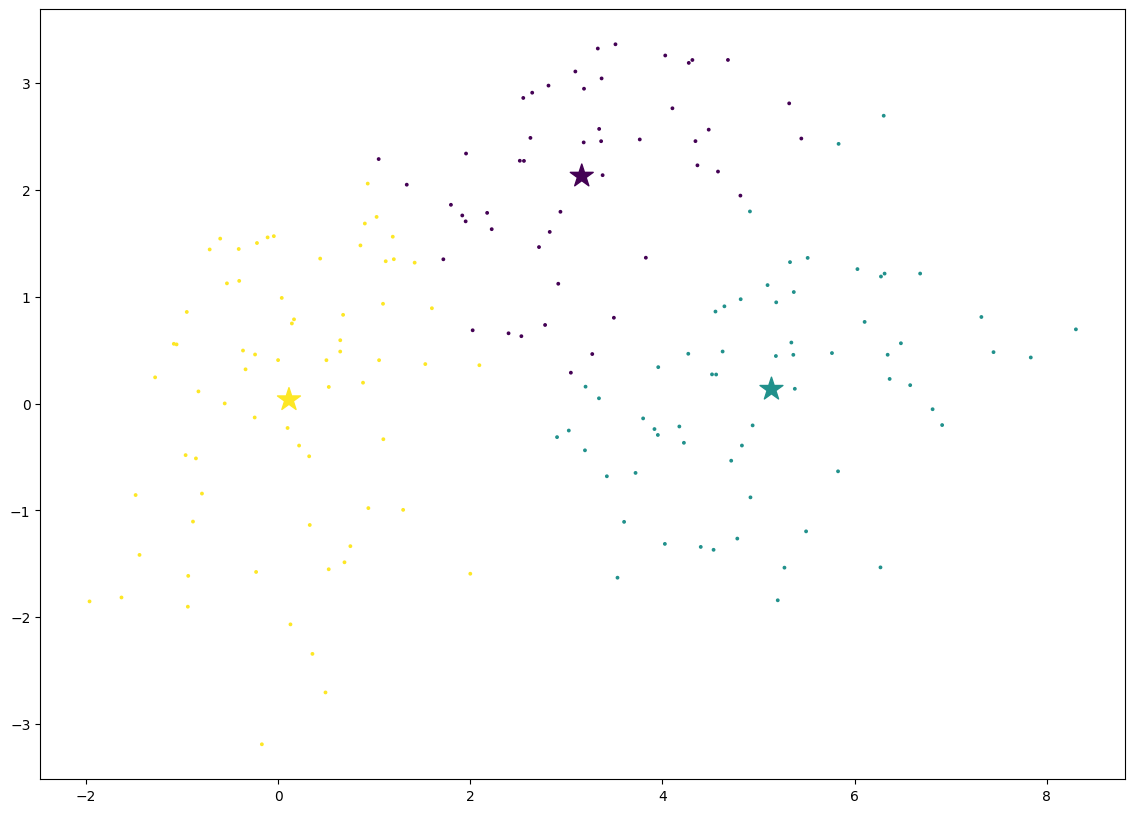

ARI score: 0.7828764282595638


In [119]:
# Step 1: Create the k_means object with the required parameters
km = k_means(data=data, d=2, k=3, tol=1e-7, max_iter=500, seed=20)

# Step 2: Fit the model
km.fit_model()

# Step 3: Plot the clusters
km.plot_clusters()

# Step 4: Compute ari_score against TRUE labels (not ref_cluster)
ari_score = clustering_eval_metrics(
    labels=np.array(km.get_labels(), dtype=int),
    true_labels=np.array(true_labels, dtype=int)
).adjusted_rand_score()

print("ARI score:", ari_score)

### <font color="Red"> Run the following code.</font> (do not change the code!)

### The following lines are tests to see whether you implemented the methods correctly

In [120]:
np.testing.assert_array_equal(km.get_labels(), ref_cluster)

In [121]:
clustering_eval_metrics(
    np.array(km.get_labels(), dtype=int), ref_cluster.astype(int)
).adjusted_rand_score()

np.float64(1.0)

In [122]:
print("ari_score:", ari_score)
print("ref_ari_score[0]:", ref_ari_score[0])
print("difference:", abs(ari_score - ref_ari_score[0]))
print("km labels:", km.get_labels()[:20])   # first 20 labels
print("ref_cluster:", ref_cluster[:20])      # first 20 reference labels

ari_score: 0.7828764282595638
ref_ari_score[0]: 0.7828764282595638
difference: 0.0
km labels: [0 0 0 1 1 0 1 2 0 1 1 0 0 1 0 2 2 0 2 1]
ref_cluster: [0. 0. 0. 1. 1. 0. 1. 2. 0. 1. 1. 0. 0. 1. 0. 2. 2. 0. 2. 1.]


In [123]:
assert abs(ari_score - ref_ari_score[0]) < 1e-2

### 3.2 How to choose k?

Above, we were using $k=3$, but it is unclear whether this is a good choice. Make a plot of within cluster sum of squares for $k$ ranging from 1 to 16, and then use the elbow method. What k you would like to use? Explain why. (Note that we can do this here because we know the truth, but of course the method itself is unsupervised.)

Notes:

**WCSS**: within-cluster sum of squares. Measures how tight/compact each cluster is, specifically how far each point is from its cluster's center.

* Smaller WCSS = better clustering
* WCSS always decreases as k increases
* We use the elbow method to find where WCSS stops dropping sharply, because that is where adding more clusters stops being worth it.

Convergence Reached! Number of iterations: 2
Convergence Reached! Number of iterations: 6
Convergence Reached! Number of iterations: 6
Convergence Reached! Number of iterations: 10
Convergence Reached! Number of iterations: 15
Convergence Reached! Number of iterations: 13
Convergence Reached! Number of iterations: 9
Convergence Reached! Number of iterations: 10
Convergence Reached! Number of iterations: 9
Convergence Reached! Number of iterations: 7
Convergence Reached! Number of iterations: 8
Convergence Reached! Number of iterations: 6
Convergence Reached! Number of iterations: 7
Convergence Reached! Number of iterations: 10
Convergence Reached! Number of iterations: 10
Convergence Reached! Number of iterations: 9


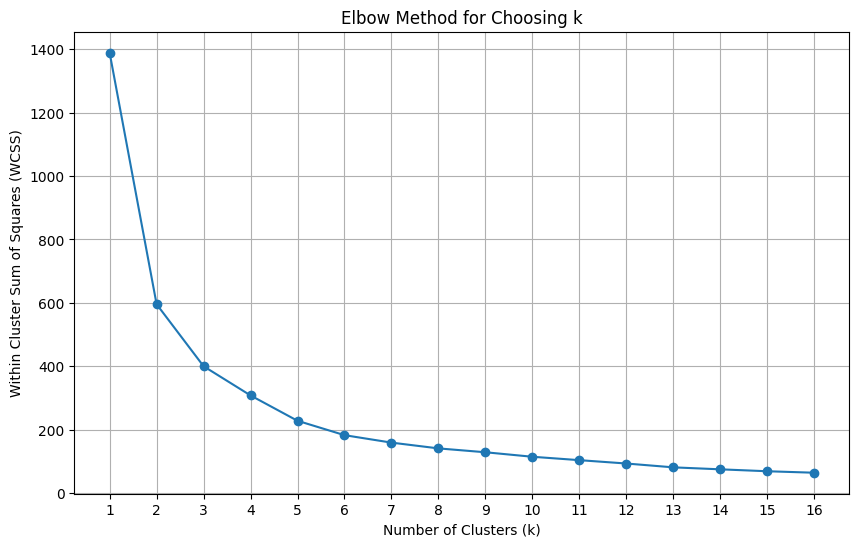

In [124]:
# Compute WCSS for k = 1 to 16
wcss = []
for k in range(1, 17):
    km_k = k_means(data=data, d=2, k=k, tol=1e-7, max_iter=500, seed=20)
    km_k.fit_model()
    wcss.append(km_k.get_cost())

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, 17), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for Choosing k")
plt.xticks(range(1,17))
plt.grid(True)
plt.show()

Answer: 

From the elbow plot, I would choose k = 3. 

The WCSS decreases sharply from k = 1 to k = 3, but after k =3 the curve flattens out significantly , the bend is the "elbow"

Byond k = 3, adding more clusters gives only marginal improvement in WCSS, meaning the extra clusters are not capturing meaningful new structure in the data.

The choice is also validated by the fact that we know the data was generated from exactly 3 Gaussian distribution, so k=3 correctly recoverse the true underlying strutcture. 

### 3.3 Are the results from k_means and k_medoids the same when p=2? Why or why not?

No, the results from k means and k-mediods are not necessarily the same when p = 2, even though they may often be similiar.

* K-means uses the centroid (the mean of all points in the cluster) as the cluster center. The centroid minimizes the within-cluster sum of squared Euclidean distances, but is not necessarily an actual data point in the dataset.

* k-medioids uses the medioid (the actual data point within the cluster that minimizes the total distance to all other points in the cluster) as the center. Because the center must be real observed data point, k-medoids is more constrained in how it can place centers.

When p =2, the centroid is the optical center mathematically, but since k-medioids is forced to pick a real data point instead, its centers will generally be slightly off from the true centroid. This means:

* The cluster assignment can differ between the two methods
* For large, well-seperated clusters they tend to agree
* For small or overlapping clusters, differences are more pronounced
* k-medoids is more robust to outliers since an outlier can only become a center if it genuinely minimizes within-cluster distances, whereas in k-means a single outlier can pull the centroid far from the bulk of cluster. 

## Part 4. Segmentation Analysis <font color="red">  </font>


### About the dataset

The dataset contains the station location and many different weather features observed at each location.
		
<h4 align = "center">
Environment Canada    
Monthly Values for July - 2015	
</h4>
<html>
<head>
<style>
table {
    font-family: arial, sans-serif;
    border-collapse: collapse;
    width: 100%;
}

td, th {
    border: 1px solid #dddddd;
    text-align: left;
    padding: 8px;
}

tr:nth-child(even) {
    background-color: #dddddd;
}
</style>
</head>
<body>

<table>
  <tr>
    <th>Name in the table</th>
    <th>Meaning</th>
  </tr>
  <tr>
    <td><font color = "green"><strong>Stn_Name</font></td>
    <td><font color = "green"><strong>Station Name</font</td>
  </tr>
  <tr>
    <td><font color = "green"><strong>Lat</font></td>
    <td><font color = "green"><strong>Latitude (North+, degrees)</font></td>
  </tr>
  <tr>
    <td><font color = "green"><strong>Long</font></td>
    <td><font color = "green"><strong>Longitude (West - , degrees)</font></td>
  </tr>
  <tr>
    <td>Prov</td>
    <td>Province</td>
  </tr>
  <tr>
    <td>Tm</td>
    <td>Mean Temperature (°C)</td>
  </tr>
  <tr>
    <td>DwTm</td>
    <td>Days without Valid Mean Temperature</td>
  </tr>
  <tr>
    <td>D</td>
    <td>Mean Temperature difference from Normal (1981-2010) (°C)</td>
  </tr>
  <tr>
    <td><font color = "black">Tx</font></td>
    <td><font color = "black">Highest Monthly Maximum Temperature (°C)</font></td>
  </tr>
  <tr>
    <td>DwTx</td>
    <td>Days without Valid Maximum Temperature</td>
  </tr>
  <tr>
    <td><font color = "black">Tn</font></td>
    <td><font color = "black">Lowest Monthly Minimum Temperature (°C)</font></td>
  </tr>
  <tr>
    <td>DwTn</td>
    <td>Days without Valid Minimum Temperature</td>
  </tr>
  <tr>
    <td>S</td>
    <td>Snowfall (cm)</td>
  </tr>
  <tr>
    <td>DwS</td>
    <td>Days without Valid Snowfall</td>
  </tr>
  <tr>
    <td>S%N</td>
    <td>Percent of Normal (1981-2010) Snowfall</td>
  </tr>
  <tr>
    <td><font color = "green"><strong>P</font></td>
    <td><font color = "green"><strong>Total Precipitation (mm)</font></td>
  </tr>
  <tr>
    <td>DwP</td>
    <td>Days without Valid Precipitation</td>
  </tr>
  <tr>
    <td>P%N</td>
    <td>Percent of Normal (1981-2010) Precipitation</td>
  </tr>
  <tr>
    <td>S_G</td>
    <td>Snow on the ground at the end of the month (cm)</td>
  </tr>
  <tr>
    <td>Pd</td>
    <td>Number of days with Precipitation 1.0 mm or more</td>
  </tr>
  <tr>
    <td>BS</td>
    <td>Bright Sunshine (hours)</td>
  </tr>
  <tr>
    <td>DwBS</td>
    <td>Days without Valid Bright Sunshine</td>
  </tr>
  <tr>
    <td>BS%</td>
    <td>Percent of Normal (1981-2010) Bright Sunshine</td>
  </tr>
  <tr>
    <td>HDD</td>
    <td>Degree Days below 18 °C</td>
  </tr>
  <tr>
    <td>CDD</td>
    <td>Degree Days above 18 °C</td>
  </tr>
  <tr>
    <td>Stn_No</td>
    <td>Climate station identifier (first 3 digits indicate   drainage basin, last 4 characters are for sorting alphabetically).</td>
  </tr>
  <tr>
    <td>NA</td>
    <td>Not Available</td>
  </tr>


</table>

</body>
</html>

 

In [125]:

filename = "/Users/arezoog/Desktop/Spring 2026/STA142B/HW2/ref_data/weather.csv"
df = pd.read_csv(filename)
df = df[pd.notnull(df["Tm"])]
df = df.reset_index(drop=True)
df.head(5)

,Stn_Name,Lat,Long,Prov,Tm,DwTm,D,Tx,DwTx,Tn,...,DwP,P%N,S_G,Pd,BS,DwBS,BS%,HDD,CDD,Stn_No
0,CHEMAINUS,48.935,-123.742,BC,8.2,0.0,NaN,13.5,0.0,1.0,...,0.0,NaN,0.0,12.0,NaN,NaN,NaN,273.3,0.0,1011500
1,COWICHAN LAKE FORESTRY,48.824,-124.133,BC,7.0,0.0,3.0,15.0,0.0,-3.0,...,0.0,104.0,0.0,12.0,NaN,NaN,NaN,307.0,0.0,1012040
2,LAKE COWICHAN,48.829,-124.052,BC,6.8,13.0,2.8,16.0,9.0,-2.5,...,9.0,NaN,NaN,11.0,NaN,NaN,NaN,168.1,0.0,1012055
3,DUNCAN KELVIN CREEK,48.735,-123.728,BC,7.7,2.0,3.4,14.5,2.0,-1.0,...,2.0,NaN,NaN,11.0,NaN,NaN,NaN,267.7,0.0,1012573
4,ESQUIMALT HARBOUR,48.432,-123.439,BC,8.8,0.0,NaN,13.1,0.0,1.9,...,8.0,NaN,NaN,12.0,NaN,NaN,NaN,258.6,0.0,1012710


In [126]:
print(df['Tm'].describe())
print("\nSample of Tm values:")
print(df['Tm'].head(20))

count    1256.000000
mean      -12.062341
std        10.416366
min       -38.200000
25%       -18.500000
50%       -13.800000
75%        -5.600000
max         9.600000
Name: Tm, dtype: float64

Sample of Tm values:
0     8.2
1     7.0
2     6.8
3     7.7
4     8.8
5     8.9
6     7.2
7     7.7
8     8.6
9     9.6
10    8.1
11    8.3
12    7.8
13    7.6
14    8.7
15    7.1
16    9.5
17    8.3
18    8.9
19    8.1
Name: Tm, dtype: float64


### Visualization of the data

Read the code below carefully to learn how to plot location data (longitude and lattitude) on a map. 

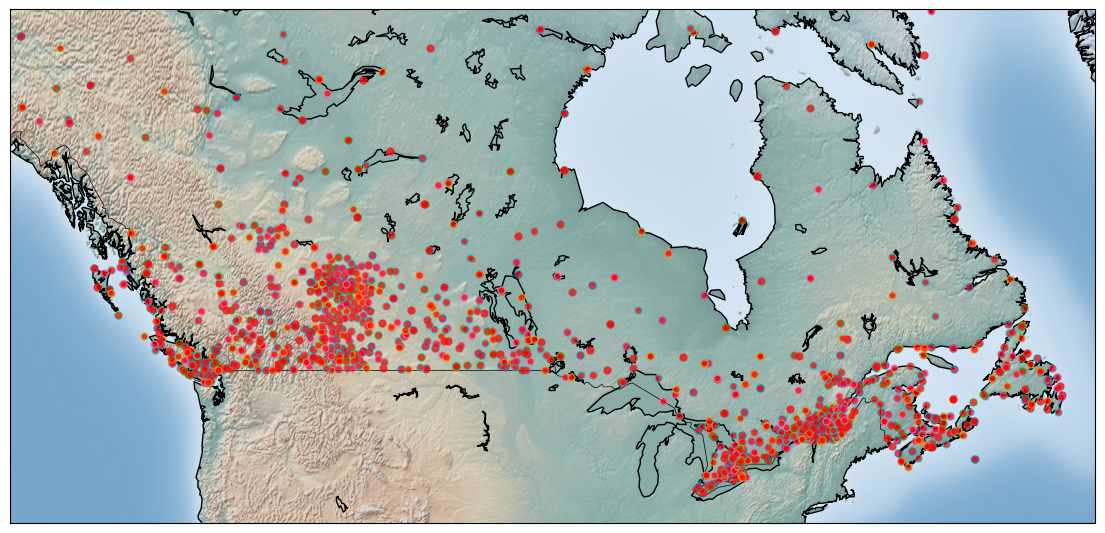

In [127]:
rcParams["figure.figsize"] = (14, 10)
llon = -140
ulon = -50
llat = 40
ulat = 65
df = df[
    (df["Long"] > llon) & (df["Long"] < ulon) & (df["Lat"] > llat) & (df["Lat"] < ulat)
]

my_map = Basemap(
    projection="merc",
    resolution="l",
    area_thresh=1000.0,
    llcrnrlon=llon,
    llcrnrlat=llat,
    urcrnrlon=ulon,
    urcrnrlat=ulat,
)
my_map.drawcoastlines()
my_map.drawcountries()
my_map.shadedrelief()


## this is to change longitude and latitude to coordinates

xs, ys = my_map(np.asarray(df.Long), np.asarray(df.Lat))
df["xm"] = xs.tolist()
df["ym"] = ys.tolist()

# plot the stations on the map
for index, row in df.iterrows():
    my_map.plot(
        row.xm,
        row.ym,
        markerfacecolor=([1, 0, 0]),
        marker="o",
        markersize=5,
        alpha=0.75,
    )
plt.show()

### In the following, you'll work on two datasets data1 (segmentation based on location data only) and data2 (segmentation based on location data as well as the temperature data) to perform k means methods with an appropriate k to do clustering and then label the clusters on two separate maps. 

- You need to justify every decision you make by appropriate plots or reasoning. For example, make a certain plot to explain your decision about which k to use.
- You need to plot the stations on a map, and color them according to their clusters. Also, plot the center of each cluster and label them using their cluster numbers 0,1,...,k-1 as label; use a large enough fontsize (fontsize=25).
- Print out the average temperature of each cluster.

In [128]:
## do not change anything in this block
data1 = df[["xm", "ym"]].to_numpy()
data2 = df[["xm", "ym", "Tx", "Tm", "Tn"]].to_numpy()

data1 = np.nan_to_num(data1)
data1 = StandardScaler().fit_transform(data1)
data2 = np.nan_to_num(data2)
data2 = StandardScaler().fit_transform(data2)

### For data1

1. Use Elbow method to pick a k.

Convergence Reached! Number of iterations: 2
Convergence Reached! Number of iterations: 5
Convergence Reached! Number of iterations: 16
Convergence Reached! Number of iterations: 15
Convergence Reached! Number of iterations: 30
Convergence Reached! Number of iterations: 45
Convergence Reached! Number of iterations: 36
Convergence Reached! Number of iterations: 9
Convergence Reached! Number of iterations: 24
Convergence Reached! Number of iterations: 37


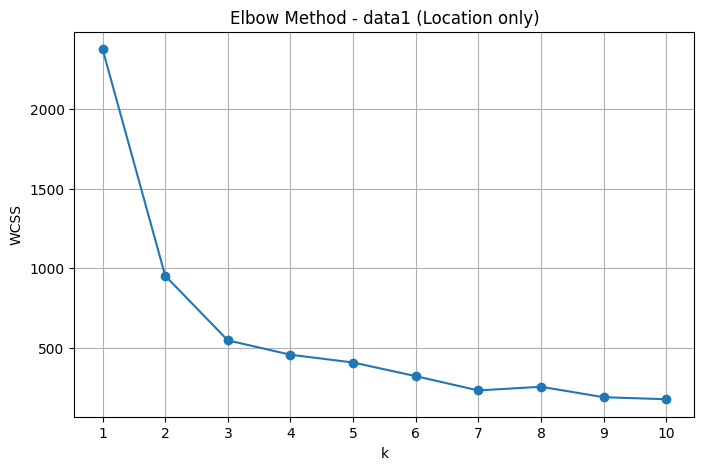

From the elbow plot, k=4 is chosen as the WCSS flattens most noticeably after k=4.


In [129]:
# Elbow method for data1 (location only: xm, ym)
wcss_data1 = []
for k in range(1, 11):
    km_tmp = k_means(data=data1, d=2, k=k, tol=1e-7, max_iter=500, seed=20)
    km_tmp.fit_model()
    wcss_data1.append(km_tmp.get_cost())

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss_data1, marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method - data1 (Location only)")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print("From the elbow plot, k=4 is chosen as the WCSS flattens most noticeably after k=4.")

**Expalanation**: 

From the elbow plot, I would choose k=4. The WCSS drops steeply 
from k=1 to k=3, but the most notable flattening occurs after k=4, 
where adding more clusters gives only marginal improvement. k=4 
best balances model complexity with cluster compactness for 
location-based segmentation of Canadian weather stations.

2. Fit a k_means model and make the plot on a map.

Convergence Reached! Number of iterations: 15


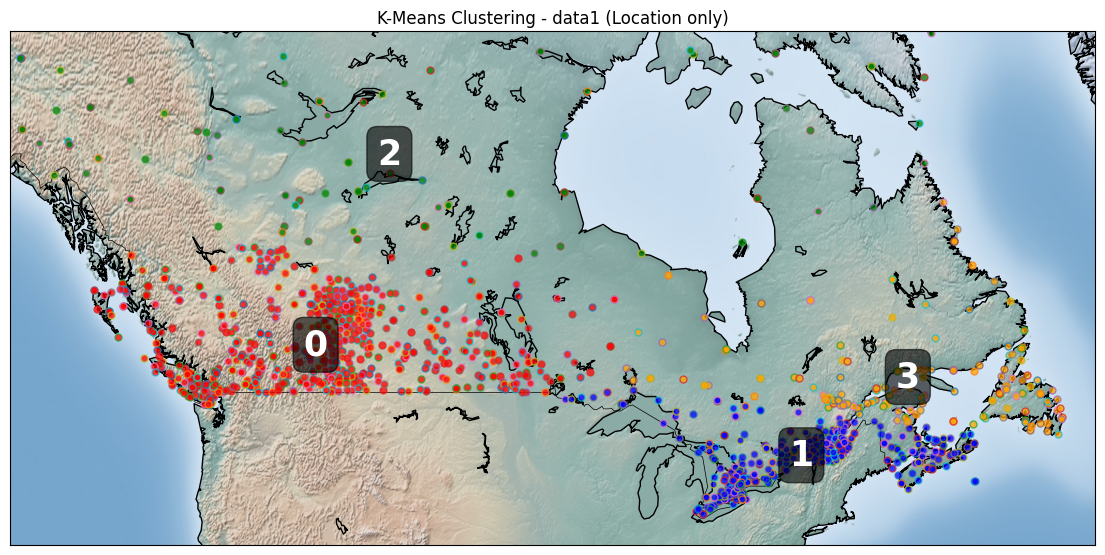

In [130]:
k1 = 4

km_data1 = k_means(data=data1, d=2, k=k1, tol=1e-7, max_iter=500, seed=20)
km_data1.fit_model()
labels_data1 = km_data1.get_labels()

# inverse transform centers back to xm, ym map coordinates
scaler1 = StandardScaler().fit(df[["xm", "ym"]].to_numpy())
centers_geo1 = scaler1.inverse_transform(km_data1.get_centers())

# Plot on map
rcParams["figure.figsize"] = (14, 10)
llon=-140; ulon=-50; llat=40; ulat=65

my_map = Basemap(projection="merc", resolution="l", area_thresh=1000.0,
    llcrnrlon=llon, llcrnrlat=llat, urcrnrlon=ulon, urcrnrlat=ulat)
my_map.drawcoastlines()
my_map.drawcountries()
my_map.shadedrelief()

# Plot each station colored by cluster
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']
for idx, row in df.reset_index(drop=True).iterrows():
    c = colors[labels_data1[idx] % len(colors)]
    my_map.plot(row.xm, row.ym, markerfacecolor=c, marker='o', markersize=5, alpha=0.75)

# Plot cluster center labels — xm/ym are already in map coordinates
for c in range(k1):
    cx = centers_geo1[c, 0]
    cy = centers_geo1[c, 1]
    plt.text(cx, cy, str(c), fontsize=25, fontweight='bold',
             color='white', ha='center', va='center',
             bbox=dict(facecolor='black', alpha=0.6, boxstyle='round'))

plt.title("K-Means Clustering - data1 (Location only)")
plt.show()

3. Print out the average temperature of each cluster.

In [131]:
df_temp = df.reset_index(drop=True)
df_temp['cluster'] = labels_data1

print("Average temperature (Tm) per cluster - data1:")
for c in range(k1):
    # only include stations with valid July temperatures (above -10°C)
    cluster_df = df_temp[(df_temp['cluster'] == c) & (df_temp['Tm'] > -10)]
    avg = cluster_df['Tm'].mean()
    count = len(cluster_df)
    print(f"  Cluster {c}: {avg:.2f} °C  ({count} stations)")

Average temperature (Tm) per cluster - data1:
  Cluster 0: 0.46 °C  (381 stations)
  Cluster 1: -7.68 °C  (26 stations)
  Cluster 2: -7.07 °C  (3 stations)
  Cluster 3: -6.38 °C  (32 stations)


### For data2

1. Use Elbow method to pick a k.

Convergence Reached! Number of iterations: 2
Convergence Reached! Number of iterations: 8
Convergence Reached! Number of iterations: 22
Convergence Reached! Number of iterations: 20
Convergence Reached! Number of iterations: 21
Convergence Reached! Number of iterations: 16
Convergence Reached! Number of iterations: 22
Convergence Reached! Number of iterations: 34
Convergence Reached! Number of iterations: 43
Convergence Reached! Number of iterations: 23


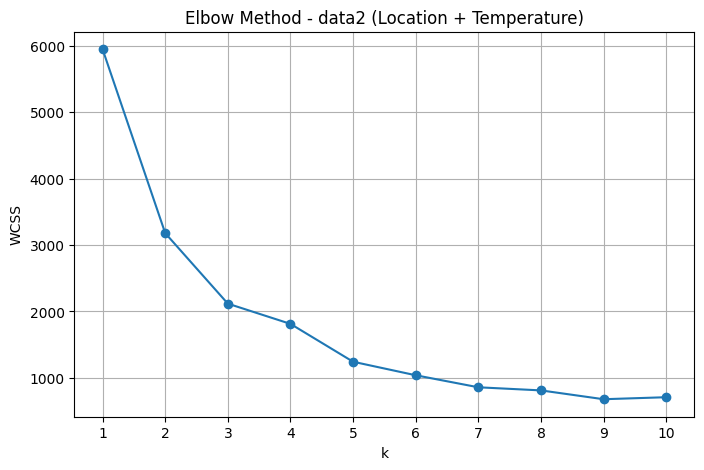

In [132]:
# Elbow method for data2 (location + temperature: xm, ym, Tx, Tm, Tn)
wcss_data2 = []
for k in range(1, 11):
    km_tmp = k_means(data=data2, d=5, k=k, tol=1e-7, max_iter=500, seed=20)
    km_tmp.fit_model()
    wcss_data2.append(km_tmp.get_cost())

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss_data2, marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method - data2 (Location + Temperature)")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

**Explanation**: 
From the elbow plot for data2, I would choose k=5. The WCSS drops 
steeply from k=1 to k=5, and after k=5 the curve flattens 
considerably. Adding temperature features (Tx, Tm, Tn) to the 
location data creates more distinct groupings than location alone, 
as stations with similar climates cluster together regardless of 
geographic proximity.


2. Fit a k_means model and make the plot on a map.

Convergence Reached! Number of iterations: 21


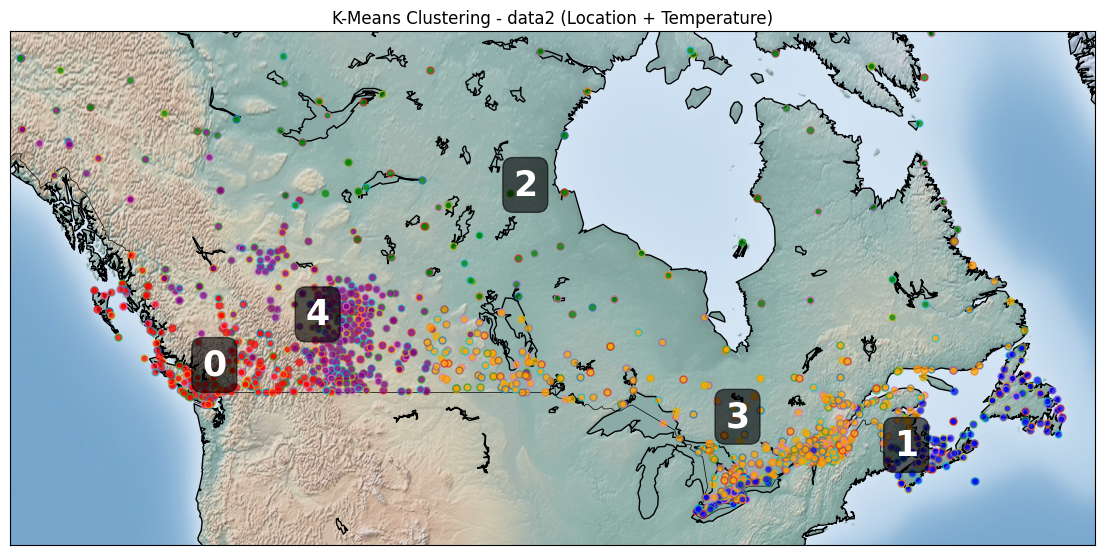

In [133]:
k2 = 5

km_data2 = k_means(data=data2, d=5, k=k2, tol=1e-7, max_iter=500, seed=20)
km_data2.fit_model()
labels_data2 = km_data2.get_labels()

# inverse transform centers — only need first 2 dims (xm, ym) for map
data2_raw = df[["xm", "ym", "Tx", "Tm", "Tn"]].to_numpy()
data2_raw = np.nan_to_num(data2_raw)
scaler2 = StandardScaler().fit(data2_raw)
centers_geo2 = scaler2.inverse_transform(km_data2.get_centers())

# Plot on map
rcParams["figure.figsize"] = (14, 10)
llon=-140; ulon=-50; llat=40; ulat=65

my_map2 = Basemap(projection="merc", resolution="l", area_thresh=1000.0,
    llcrnrlon=llon, llcrnrlat=llat, urcrnrlon=ulon, urcrnrlat=ulat)
my_map2.drawcoastlines()
my_map2.drawcountries()
my_map2.shadedrelief()

# Plot each station colored by its cluster
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']
df_reset = df.reset_index(drop=True)
for idx, row in df_reset.iterrows():
    c = colors[labels_data2[idx] % len(colors)]
    my_map2.plot(row.xm, row.ym, markerfacecolor=c, marker='o', markersize=5, alpha=0.75)

# Plot cluster centers — xm/ym already in map coordinates
for c in range(k2):
    cx = centers_geo2[c, 0]
    cy = centers_geo2[c, 1]
    plt.text(cx, cy, str(c), fontsize=25, fontweight='bold',
             color='white', ha='center', va='center',
             bbox=dict(facecolor='black', alpha=0.6, boxstyle='round'))

plt.title("K-Means Clustering - data2 (Location + Temperature)")
plt.show()

3. Print out the average temperature of each cluster.

In [134]:
df_temp2 = df.reset_index(drop=True)
df_temp2['cluster'] = labels_data2

print("Average temperature (Tm) per cluster - data2:")
for c in range(k2):
    cluster_df = df_temp2[df_temp2['cluster'] == c]
    avg = cluster_df['Tm'].mean()
    count = len(cluster_df)
    print(f"  Cluster {c}: {avg:.2f} °C  ({count} stations)")

Average temperature (Tm) per cluster - data2:
  Cluster 0: 4.94 °C  (226 stations)
  Cluster 1: -10.04 °C  (147 stations)
  Cluster 2: -25.38 °C  (100 stations)
  Cluster 3: -18.00 °C  (410 stations)
  Cluster 4: -9.62 °C  (306 stations)


**Explanation**: From the elbow plot for data2, k=5 is chosen. The WCSS drops 
significantly up to k=5, after which the curve flattens 
considerably. Unlike data1 (location only), adding temperature 
features creates 5 meaningful climate zones across Canada, visible 
on the map: the warm Pacific coast (Cluster 0), Atlantic Canada 
(Cluster 1), the cold Arctic north (Cluster 2), central Canada 
(Cluster 3), and the interior prairies (Cluster 4). The average 
temperatures confirm this — ranging from +4.94°C on the coast 
to -25.38°C in the far north.

## Part 5. (This is question 9 from James et al. 2013, Introduction to Statistical Learning) 
Consider the USArrests data (you find it in the "Data" folder in "files" on colab). We will now perform hierarchical clustering on the states.

In [135]:
data_USArrests = pd.read_csv("/Users/arezoog/Desktop/Spring 2026/STA142B/HW2/ref_data/USArrests.csv")       #<==== you might have to adjust according to your environment
data_USArrests.rename(columns = {'Unnamed: 0': 'State'}, inplace=True)
data_USArrests.set_index("State", inplace=True)

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

### (a) Using hierarchical clustering with complete linkage (with Euclidean distance), cluster the states. Show different clusters by different colors.

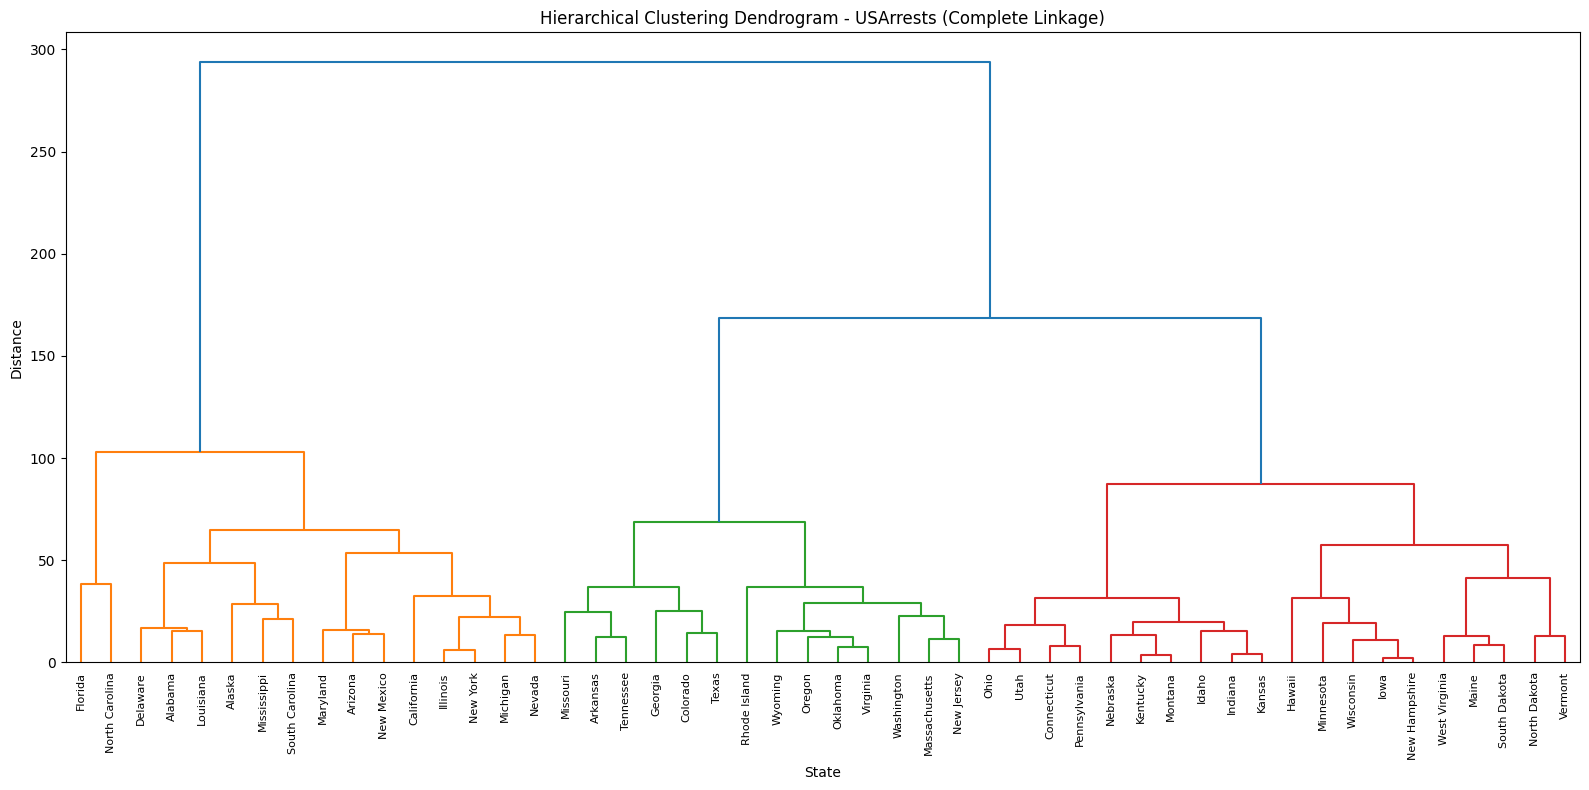

In [136]:
### your code starts here

# Compute linkage matrix using complete linkage and Euclidean distance
Z = linkage(data_USArrests, method='complete', metric='euclidean')

# Plot dendrogram with colors
plt.figure(figsize=(16, 8))
dendrogram(Z, 
           labels=data_USArrests.index.tolist(),
           leaf_rotation=90,
           leaf_font_size=8,
           color_threshold=150)
plt.title("Hierarchical Clustering Dendrogram - USArrests (Complete Linkage)")
plt.xlabel("State")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()



### (b) Cut the dendrogram at a height that results in three distinct clusters. Which states belong to which clusters?

In [137]:
# Cut dendrogram to get 3 clusters
model_3 = AgglomerativeClustering(n_clusters=3, linkage='complete')
cluster_labels_3 = model_3.fit_predict(data_USArrests)

# Print which states belong to each cluster
for cluster_id in range(3):
    states = data_USArrests.index[cluster_labels_3 == cluster_id].tolist()
    print(f"\nCluster {cluster_id}:")
    print(states)


Cluster 0:
['Alabama', 'Alaska', 'Arizona', 'California', 'Delaware', 'Florida', 'Illinois', 'Louisiana', 'Maryland', 'Michigan', 'Mississippi', 'Nevada', 'New Mexico', 'New York', 'North Carolina', 'South Carolina']

Cluster 1:
['Connecticut', 'Hawaii', 'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Maine', 'Minnesota', 'Montana', 'Nebraska', 'New Hampshire', 'North Dakota', 'Ohio', 'Pennsylvania', 'South Dakota', 'Utah', 'Vermont', 'West Virginia', 'Wisconsin']

Cluster 2:
['Arkansas', 'Colorado', 'Georgia', 'Massachusetts', 'Missouri', 'New Jersey', 'Oklahoma', 'Oregon', 'Rhode Island', 'Tennessee', 'Texas', 'Virginia', 'Washington', 'Wyoming']


#### Which states belong to cluster 0

['Alabama', 'Alaska', 'Arizona', 'California', 'Delaware', 'Florida', 'Illinois', 'Louisiana', 'Maryland', 'Michigan', 'Mississippi', 'Nevada', 'New Mexico', 'New York', 'North Carolina', 'South Carolina']

#### Which states belong to cluster 1

['Connecticut', 'Hawaii', 'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Maine', 'Minnesota', 'Montana', 'Nebraska', 'New Hampshire', 'North Dakota', 'Ohio', 'Pennsylvania', 'South Dakota', 'Utah', 'Vermont', 'West Virginia', 'Wisconsin']


#### Which states belong to cluster 2

['Arkansas', 'Colorado', 'Georgia', 'Massachusetts', 'Missouri', 'New Jersey', 'Oklahoma', 'Oregon', 'Rhode Island', 'Tennessee', 'Texas', 'Virginia', 'Washington', 'Wyoming']

### (c) Hierarchically cluster the states using complete linkage and Euclidean distance, after scaling the variables to have standard deviation one.

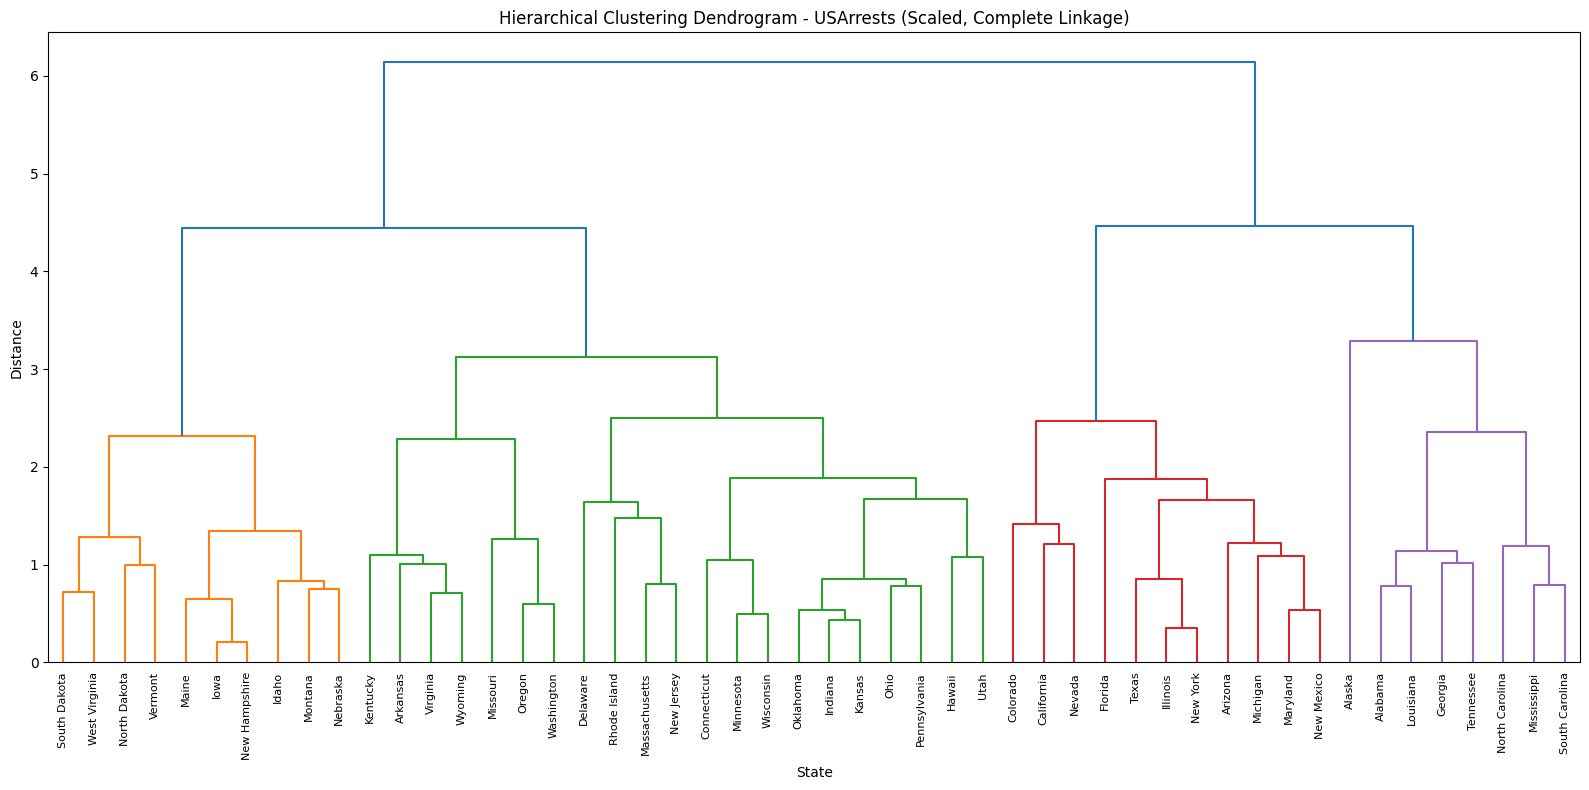


Cluster 0 (scaled):
['Arkansas', 'Connecticut', 'Delaware', 'Hawaii', 'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Maine', 'Massachusetts', 'Minnesota', 'Missouri', 'Montana', 'Nebraska', 'New Hampshire', 'New Jersey', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Dakota', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

Cluster 1 (scaled):
['Alabama', 'Alaska', 'Georgia', 'Louisiana', 'Mississippi', 'North Carolina', 'South Carolina', 'Tennessee']

Cluster 2 (scaled):
['Arizona', 'California', 'Colorado', 'Florida', 'Illinois', 'Maryland', 'Michigan', 'Nevada', 'New Mexico', 'New York', 'Texas']


In [138]:
### your code starts here

from sklearn.preprocessing import StandardScaler

# Scale variables to have standard deviation = 1
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_USArrests)

# Compute linkage on scaled data
Z_scaled = linkage(data_scaled, method='complete', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(16, 8))
dendrogram(Z_scaled,
           labels=data_USArrests.index.tolist(),
           leaf_rotation=90,
           leaf_font_size=8,
           color_threshold=4)
plt.title("Hierarchical Clustering Dendrogram - USArrests (Scaled, Complete Linkage)")
plt.xlabel("State")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Show 3 clusters on scaled data
model_scaled = AgglomerativeClustering(n_clusters=3, linkage='complete')
cluster_labels_scaled = model_scaled.fit_predict(data_scaled)

for cluster_id in range(3):
    states = data_USArrests.index[cluster_labels_scaled == cluster_id].tolist()
    print(f"\nCluster {cluster_id} (scaled):")
    print(states)





### (d) What effect does scaling the variables have on the hierarchical clustering obtained? In your opinion, should the variables be scaled before the inter-observation dissimilarities are computed? Provide a justification for your answer.

Scaling the variables significantly changes the hierarchical 
clustering results, both in terms of which states are grouped 
together and the overall structure of the dendrogram.

**Effect of scaling:**
Without scaling, the Assault variable (ranging from 45–337) 
dominates the Euclidean distance calculation because it has much 
larger numerical values than Murder (0.8–17.4) or Rape (7.3–46.0). 
This means unscaled clustering is essentially driven almost 
entirely by assault rates, with the other variables having 
minimal influence.

After scaling to unit standard deviation, all four variables 
(Murder, Assault, Rape, UrbanPop) contribute equally to the 
distance. This produces meaningfully different clusters, for 
example, Tennessee and Georgia move from Cluster 2 to Cluster 1 
(high overall crime), and many mid-crime states reorganize 
differently.

**Should variables be scaled?**
Yes, in my opinion variables should be scaled before computing 
inter-observation dissimilarities. The reasons are:

1. The variables are measured in different units: Murder and 
   Rape are rates per 100,000 people, while UrbanPop is a 
   percentage. There is no meaningful reason why a one-unit 
   difference in Assault should count the same as a one-unit 
   difference in Murder.

2. Without scaling, high-variance variables unfairly dominate 
   the clustering, making the results sensitive to the choice 
   of measurement scale rather than reflecting true similarity 
   between states.

3. The scaled clustering produces more interpretable results — 
   Cluster 1 (scaled) clearly captures the high overall crime 
   Southern states, Cluster 2 captures high-crime urban states, 
   and Cluster 0 captures the safer, more rural states. This 
   three-way split aligns better with known patterns of crime 
   in the US than the unscaled version.

# <font color="blue"> Submission Instructions</font>

1. Click the Save button at the top of the Jupyter Notebook.
2. Select Cell -> All Output -> Clear. This will clear all the outputs from all cells (but will keep the content of the cells). 
3. Select Cell -> Run All. This will run all the cells in order, and will take several minutes. <font color='red'>You will not get any grade if you don't follow this step strictly.</font>
4. Once you've rerun everything, select File -> Download as -> PDF via LaTeX (You would need to install [pandoc](https://pandoc.org/installing.html) and latex. See the link for instructions.) **Or, a simpler way is to select File -> Download as -> html**. But because gradescope only accepts PDF, you can use the web browser (e.g. Chrome) feature of print to PDF. Make sure that when doing so, place the html under the same folder with all you figures. 
5. Look at the PDF file and make sure all your solutions are there, displayed correctly. 
6. Submit your PDF and ipynb file on Gradescope.
